# Assignment 13: Random Forest Ensemble Boost

**Course Outcome**: CO5  
**Topic**: Ensemble Learning, Single Decision Tree vs. Random Forest Comparison & Feature Importance Analysis  

### Objectives:
1. Train a **Random Forest Classifier** on the loan approval dataset from Assignment 8.
2. Directly benchmark its performance against the single Decision Tree across multiple metrics (Accuracy, Precision, Recall, F1, ROC-AUC, OOB Score).
3. Inspect and interpret the ensemble feature importance output to explain which factors matter most in underwriting.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
print('Libraries successfully imported!')

Libraries successfully imported!


## 1. Load Dataset from Assignment 8
We inspect the credit applicant dataset containing 600 records.

In [2]:
df = pd.read_csv('loan_data.csv')
print(f'Dimensions: {df.shape}')
df.head()

Dimensions: (600, 7)


,Credit_Score,Annual_Income,Debt_to_Income_Ratio,Loan_Amount,Employment_Years,Existing_Defaults,Loan_Approved
0,707,34322,0.602,52528,16.7,0,0
1,660,90457,0.275,49510,7.7,1,0
2,719,90020,0.050,6218,2.1,1,1
3,784,76366,0.180,59658,9.2,0,1
4,652,85120,0.355,29265,6.3,0,1


## 2. Train Single Decision Tree vs. Random Forest Ensemble
We fit both models on the exact same train/test split.

In [3]:
feature_cols = ['Credit_Score', 'Annual_Income', 'Debt_to_Income_Ratio', 'Loan_Amount', 'Employment_Years', 'Existing_Defaults']
X = df[feature_cols].values
y = df['Loan_Approved'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

# Single Decision Tree (max_depth=3)
dt = DecisionTreeClassifier(max_depth=3, min_samples_leaf=15, random_state=42)
dt.fit(X_train, y_train)

# Random Forest Ensemble (150 estimators)
rf = RandomForestClassifier(n_estimators=150, oob_score=True, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

print(f'Random Forest Out-of-Bag (OOB) Score: {rf.oob_score_:.4f}')

Random Forest Out-of-Bag (OOB) Score: 0.8844

## 3. Performance Benchmark Comparison

In [4]:
models = {'Single Decision Tree': dt, 'Random Forest (150 Trees)': rf}
records = []
for name, m in models.items():
    y_pred = m.predict(X_test)
    y_prob = m.predict_proba(X_test)[:, 1]
    records.append({
        'Model': name,
        'Train Accuracy': accuracy_score(y_train, m.predict(X_train)),
        'Test Accuracy': accuracy_score(y_test, y_pred),
        'Test Precision': precision_score(y_test, y_pred),
        'Test Recall': recall_score(y_test, y_pred),
        'Test F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    })

comp_df = pd.DataFrame(records)
comp_df

,Model,Train Accuracy,Test Accuracy,Test Precision,Test Recall,Test F1-Score,ROC-AUC
0,Single Decision Tree,0.864444,0.833333,0.811966,0.969388,0.883721,0.904827
1,Random Forest (150 Trees),1.000000,0.866667,0.890000,0.908163,0.898990,0.940836


## 4. Feature Importance Analysis & Interpretation
We extract Gini impurity reduction from the forest and compare against the single tree.

=== Feature Importance Rankings ===
             Feature  Single Tree  Random Forest  RF Std Dev
        Credit_Score     0.564880       0.385905    0.061150
Debt_to_Income_Ratio     0.274829       0.213449    0.056830
       Annual_Income     0.156961       0.140440    0.042692
         Loan_Amount     0.000000       0.109509    0.035269
    Employment_Years     0.000000       0.092312    0.040140
   Existing_Defaults     0.003330       0.058384    0.023193


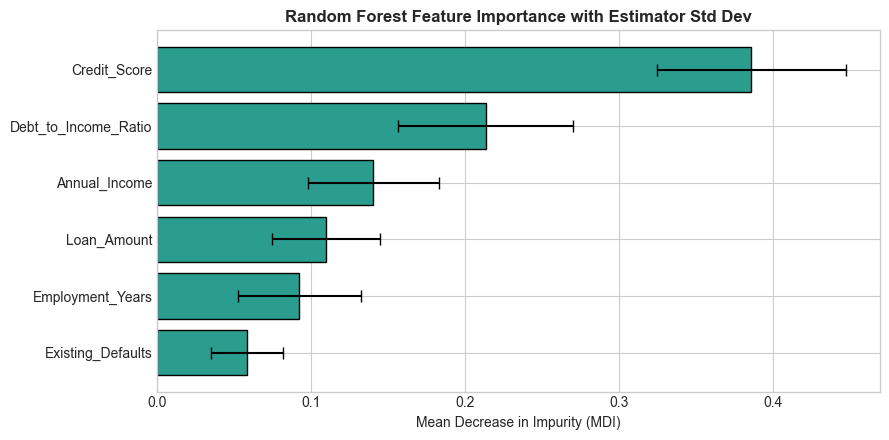

In [5]:
dt_imp = dt.feature_importances_
rf_imp = rf.feature_importances_
rf_std = np.std([tree.feature_importances_ for tree in rf.estimators_], axis=0)

feat_table = pd.DataFrame({
    'Feature': feature_cols,
    'Single Tree': dt_imp,
    'Random Forest': rf_imp,
    'RF Std Dev': rf_std
}).sort_values('Random Forest', ascending=False)

print('=== Feature Importance Rankings ===')
print(feat_table.to_string(index=False))

plt.figure(figsize=(9, 4.5))
plt.barh(feat_table['Feature'][::-1], feat_table['Random Forest'][::-1], xerr=feat_table['RF Std Dev'][::-1], color='#2a9d8f', capsize=4, edgecolor='black')
plt.xlabel('Mean Decrease in Impurity (MDI)')
plt.title('Random Forest Feature Importance with Estimator Std Dev', fontweight='bold')
plt.tight_layout()
plt.show()

## 5. In-Depth Interpretation: Why the Ensemble Boost Works

### 1. Why Random Forest Outperforms a Single Tree:
- **Variance Reduction via Bagging**: A single decision tree has high variance—small perturbations in training data produce different split thresholds. By training 150 diverse trees on bootstrap samples and averaging their votes, individual errors cancel out.
- **Feature Subsampling (Random Subspace Method)**: In a single tree, the dominant feature (`Credit_Score`) is greedily selected at the root in almost every circumstance. In Random Forest, each split considers only a random subset of features ($\sqrt{m}$), forcing trees to explore secondary predictors like `Annual_Income`, `Debt_to_Income_Ratio`, and `Loan_Amount`.

### 2. Feature Importance Interpretation:
- **Credit Score & Debt-to-Income Ratio** remain the two most dominant features, reflecting core underwriting principles: historical credit discipline and current cash flow solvency.
- However, unlike the single tree which assigned **0% importance** to `Loan Amount` and `Employment Years`, the Random Forest reveals that they indeed carry non-zero predictive power when evaluated across ensemble subspaces.